In [1]:
import warnings, time
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set(style="whitegrid")
from pathlib import Path


from pmdarima import auto_arima
from pmdarima.arima import ndiffs, nsdiffs

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera



import joblib, json

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv('E:\Document\PROJECT_1\data\data (2023-2024).csv')
df['Local Time'] = pd.to_datetime(df['Local Time'])
df.set_index('Local Time', inplace=True)


df_pm25 = df[['PM25']].resample('D').mean().asfreq('D')
df_pm25['PM25'] = df_pm25['PM25'].interpolate(limit_direction='both')


In [3]:
def transform(s):
    return np.log(s + 1e-6)

def inv_transform(s_t):
    return np.exp(s_t) - 1e-6

y = df_pm25['PM25'].dropna()
cutoff_test = int(len(y) * 0.8)

y_all_t = transform(y)
y_train = y_all_t.iloc[:cutoff_test].copy()
y_test  = y_all_t.iloc[cutoff_test:].copy()

print("Train:", y_train.index.min(), "->", y_train.index.max(), len(y_train))
print("Test :", y_test.index.min(), "->", y_test.index.max(), len(y_test))


Train: 2023-01-01 00:00:00 -> 2024-08-06 00:00:00 584
Test : 2024-08-07 00:00:00 -> 2024-12-31 00:00:00 147


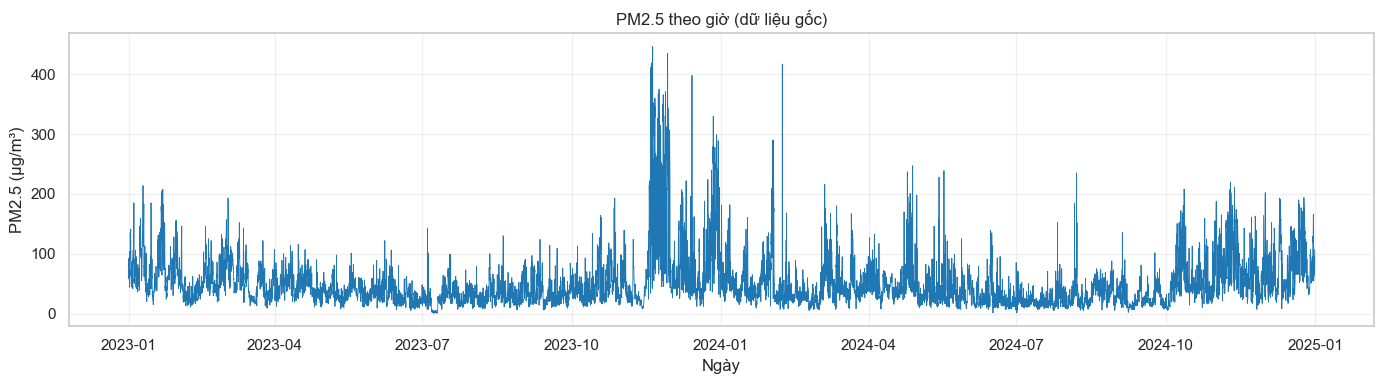

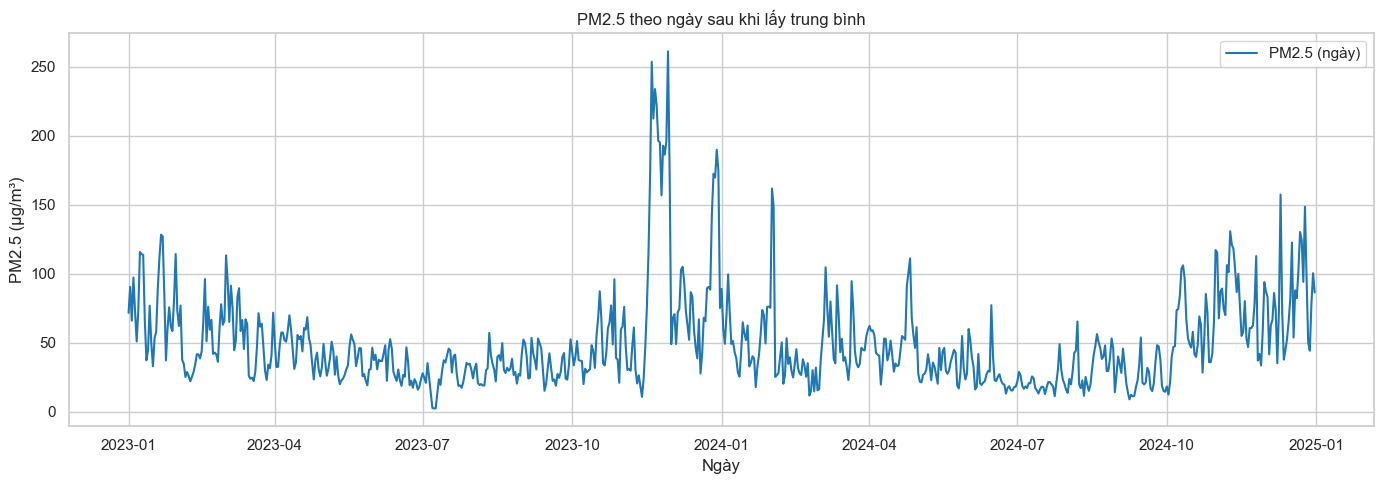

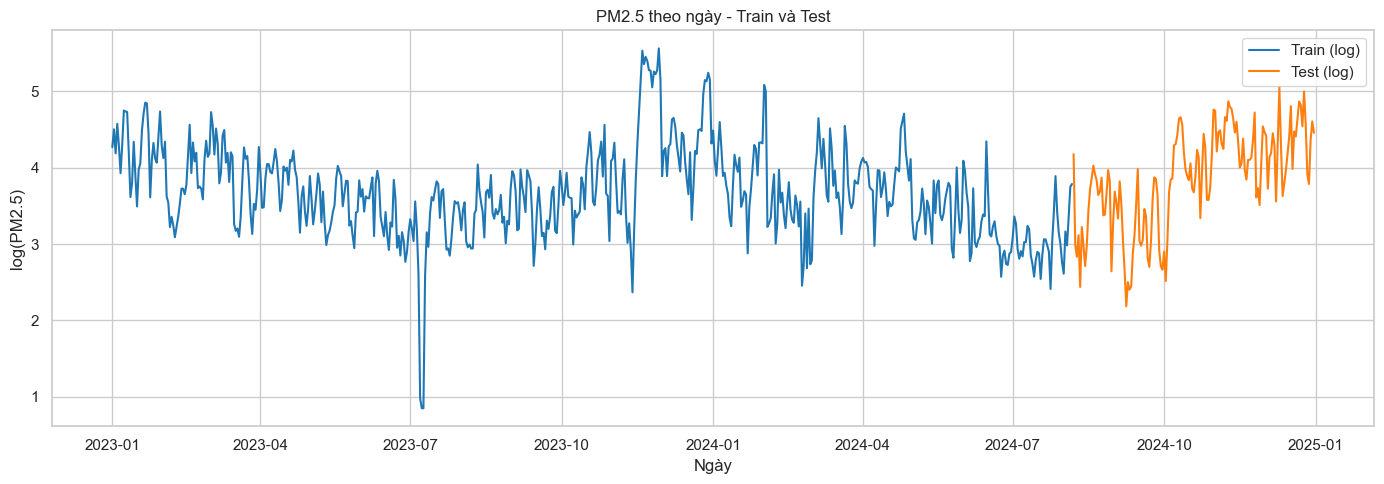

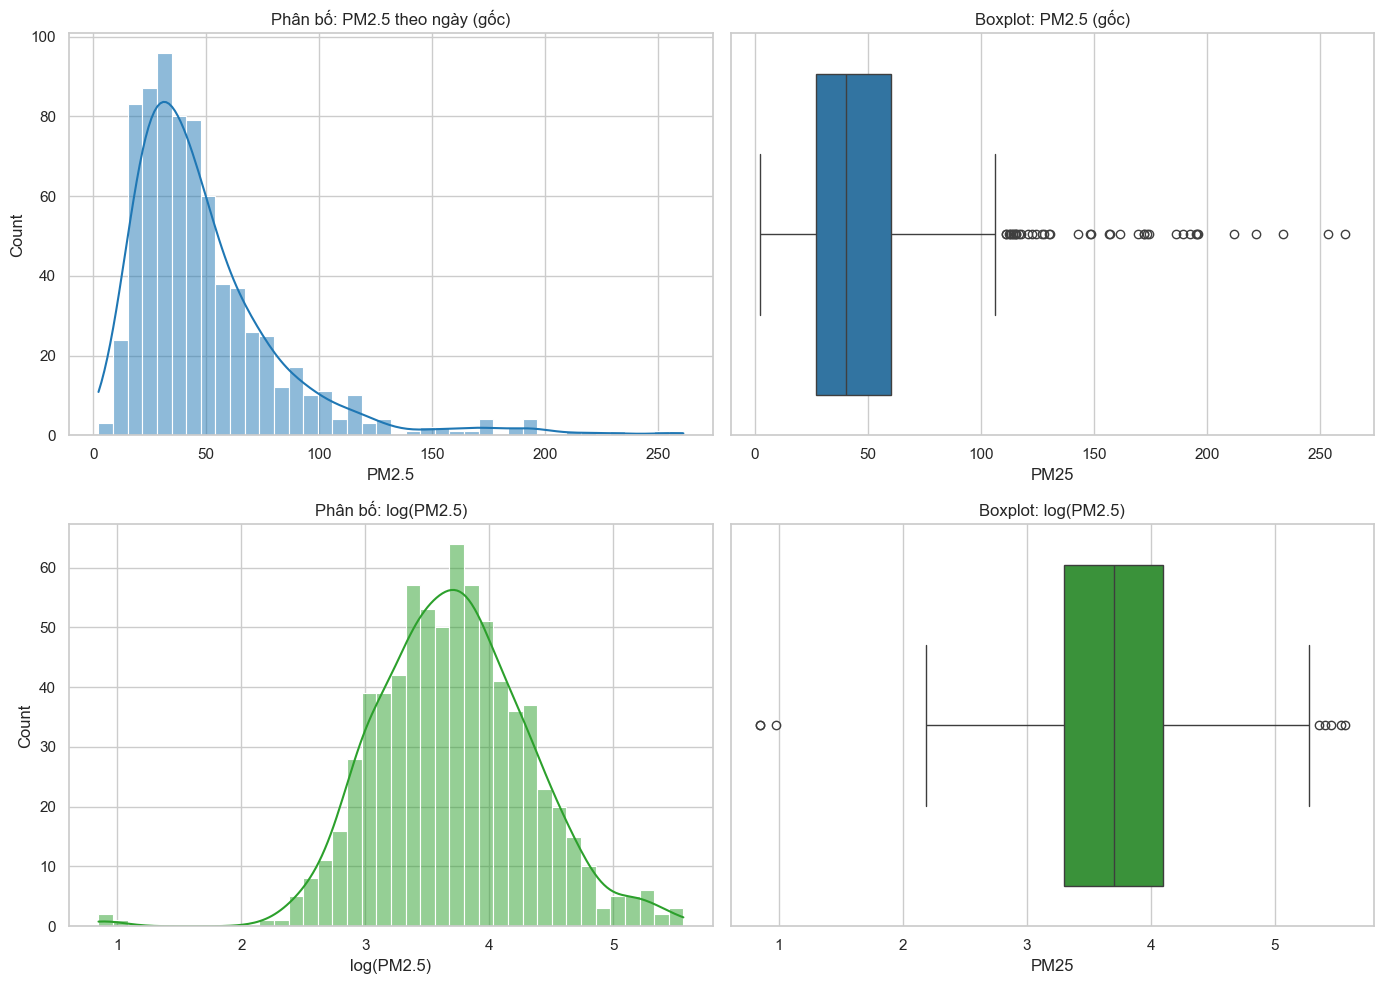

In [4]:
# ----- 1) Hourly raw series (dữ liệu gốc theo giờ) -----
fig, ax = plt.subplots(1,1, figsize=(14,4))
ax.plot(df.index, df['PM25'], color='tab:blue', linewidth=0.6)
ax.set_title('PM2.5 theo giờ (dữ liệu gốc)')
ax.set_xlabel('Ngày')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ----- 2) PM2.5 theo ngày (toàn bộ) -----
plt.figure(figsize=(14,5))
plt.plot(y.index, y.values, color='tab:blue', label='PM2.5 (ngày)')

plt.title('PM2.5 theo ngày sau khi lấy trung bình')
plt.xlabel('Ngày')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.tight_layout()
plt.show()

# ----- 3) Train vs Test (daily) -----
plt.figure(figsize=(14,5))
# vẽ lại trên scale đã transform để thống nhất (hoặc bạn có thể vẽ đảo transform)
plt.plot(y_train.index, y_train.values, label='Train (log)', color='tab:blue')
plt.plot(y_test.index, y_test.values, label='Test (log)', color='tab:orange')
plt.title('PM2.5 theo ngày - Train và Test')
plt.xlabel('Ngày')
plt.ylabel('log(PM2.5)')
plt.legend()
plt.tight_layout()
plt.show()

# ----- 4) Histogram & boxplot trước và sau log-transform -----
y_orig = y.dropna()
y_log = y_all_t.dropna()

fig, axes = plt.subplots(2,2, figsize=(14,10))
sns.histplot(y_orig, bins=40, ax=axes[0,0], kde=True, color='tab:blue')
axes[0,0].set_title('Phân bố: PM2.5 theo ngày (gốc)')
axes[0,0].set_xlabel('PM2.5')

sns.boxplot(x=y_orig, ax=axes[0,1], color='tab:blue')
axes[0,1].set_title('Boxplot: PM2.5 (gốc)')

sns.histplot(y_log, bins=40, ax=axes[1,0], kde=True, color='tab:green')
axes[1,0].set_title('Phân bố: log(PM2.5)')
axes[1,0].set_xlabel('log(PM2.5)')

sns.boxplot(x=y_log, ax=axes[1,1], color='tab:green')
axes[1,1].set_title('Boxplot: log(PM2.5)')

plt.tight_layout()
plt.show()

Kiểm định ADF/KPSS trên y_train:
ADF statistic: -5.8305 | p-value: 0.0000
Critical Values: {'1%': -3.4416553818946145, '5%': -2.8665274458710064, '10%': -2.5694261699959413}
=> stationary (không cần sai phân)
KPSS statistic: 0.2720 | p-value: 0.1000
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
=> stationary (không reject H0)
pmdarima gợi ý: d = 0 , D = 0 (m=7)


C:\Users\hungd\AppData\Local\Temp\ipykernel_8404\204366542.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res = kpss(series.dropna(), regression='c', nlags='auto')


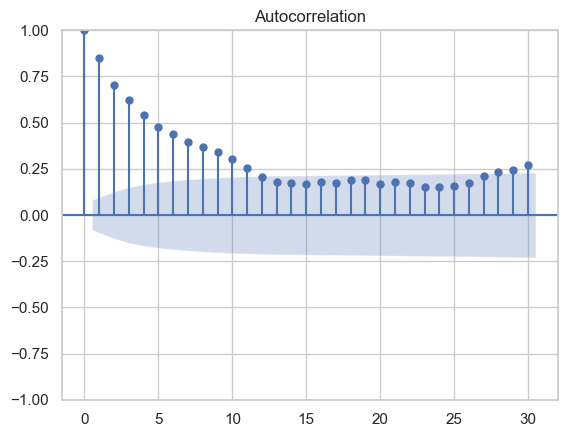

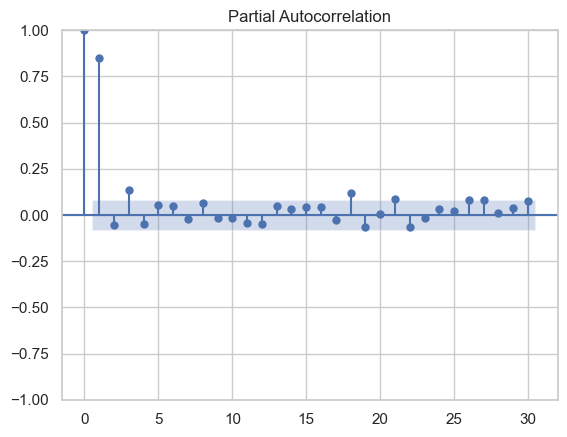

In [5]:
# CELL 5: kiểm ADF/KPSS để quyết differencing, vẽ ACF/PACF để gợi ý p/q
def adf_test(series):
    res = adfuller(series.dropna(), autolag='AIC')
    print("ADF statistic: %.4f | p-value: %.4f" % (res[0], res[1]))
    print("Critical Values:", res[4])
    print("=>", "stationary (không cần sai phân)" if res[1]<0.05 else "non-stationary (cần sai phân)")

def kpss_test(series):
    res = kpss(series.dropna(), regression='c', nlags='auto')
    print("KPSS statistic: %.4f | p-value: %.4f" % (res[0], res[1]))
    print("Critical Values:", res[3])
    print("=>", "non-stationary (reject H0)" if res[1]<0.05 else "stationary (không reject H0)")

# Dùng y_train (thang gốc) để kiểm
y_train_goc = y.iloc[:cutoff_test]
print("Kiểm định ADF/KPSS trên y_train:")
adf_test(y_train_goc)
kpss_test(y_train_goc)

# pmdarima gợi ý d và D
d_suggest = ndiffs(y_train_goc, test='adf')
D_suggest = nsdiffs(y_train_goc, m=7, test='ch')
print("pmdarima gợi ý: d =", d_suggest, ", D =", D_suggest, "(m=7)")

# Vẽ ACF và PACF để tham khảo (gốc)
plot_acf(y_train_goc.dropna(), lags=30)
plt.show()
plot_pacf(y_train_goc.dropna(), lags=30, method='ywm')
plt.show()


Trong bài báo ["Day-of-week and seasonal patterns of PM2.5 concentrations over the United States: Time-series analyses using the Prophet procedure"](https://www.sciencedirec.com/science/article/abs/pii/S1352231018305715), tác giả dùng phương pháp phân rã chuỗi thời gian (time-series decomposition) và tìm được rằng:“We observed periodically changing patterns of PM2.5 concentrations weekly and yearly.”(Chúng tôi quan sát được rằng nồng độ PM2.5 thay đổi theo chu kỳ hàng tuần và hàng năm.)

In [6]:


step = auto_arima(y_train, seasonal=True, m=7, trace=False,
                  max_p=7, max_q=4, max_P=2, max_Q=2,
                  d=None, D=None, stepwise=True, error_action='ignore', suppress_warnings=True)
order0 = step.order
seasonal0 = step.seasonal_order
print("auto_arima::", order0, seasonal0)


p0,d0,q0 = order0
p_range = list(range(max(0,p0-1), p0+2))
q_range = list(range(max(0,q0-1), q0+2))
candidates = [(p,d0,q) for p in p_range for q in q_range]



auto_arima:: (1, 1, 2) (1, 0, 0, 7)


In [7]:
# 1) Kỳ nghỉ
holiday_periods = {
    'Tết 2023': ('2023-01-20', '2023-01-26'),
    'Lễ 30/4-1/5 2023': ('2023-04-29', '2023-05-03'),
    'Lễ 2/9 2023': ('2023-08-31', '2023-09-04'),
    'Tết Dương 2024': ('2023-12-30', '2024-01-01'),
    'Tết 2024': ('2024-02-08', '2024-02-14'),
    'Lễ 30/4-1/5 2024': ('2024-04-27', '2024-05-01'),
    'Lễ 2/9 2024': ('2024-08-31', '2024-09-03'),
}

# 2) Xây exog_df (daily)
#    - Pollutant: mean theo ngày
#    - Thời tiết: mưa dùng sum, rain_hours dùng sum, các biến khác dùng mean

pollutant_cols = ['PM10', 'NO2', 'SO2']
weather_cols    = ['Pressure', 'Temperature', 'Wind Speed', 'Precipitation', 'Relative Humidity']

pollutant_cols = [c for c in pollutant_cols if c in df.columns]
weather_cols   = [c for c in weather_cols   if c in df.columns]

# index daily chung: dùng index của chuỗi PM2.5 theo ngày
exog_df = pd.DataFrame(index=df_pm25.index)

# pollutant: daily mean
for c in pollutant_cols:
    exog_df[c] = df[c].resample('D').mean().reindex(exog_df.index)

# thời tiết
if 'Pressure' in weather_cols:
    exog_df['pressure'] = df['Pressure'].resample('D').mean().reindex(exog_df.index)

if 'Temperature' in weather_cols:
    exog_df['temperature'] = df['Temperature'].resample('D').mean().reindex(exog_df.index)

if 'Wind Speed' in weather_cols:
    exog_df['wind_speed'] = df['Wind Speed'].resample('D').mean().reindex(exog_df.index)

if 'Relative Humidity' in weather_cols:
    exog_df['humidity'] = df['Relative Humidity'].resample('D').median().reindex(exog_df.index)

if 'Precipitation' in weather_cols:
    # lượng mưa theo ngày
    exog_df['rain'] = df['Precipitation'].resample('D').sum().reindex(exog_df.index)
    # số giờ có mưa trong ngày
    rain_flag = (df['Precipitation'] > 0).astype(int)
    exog_df['rain_hours'] = rain_flag.resample('D').sum().reindex(exog_df.index)

exog_df = exog_df.asfreq('D')

# 3) Cờ weekend/holiday (+lag)
exog_df['IsWeekend'] = exog_df.index.dayofweek.isin([5, 6]).astype(int)
exog_df['IsHoliday'] = 0
for _, (start, end) in holiday_periods.items():
    exog_df.loc[(exog_df.index >= start) & (exog_df.index <= end), 'IsHoliday'] = 1

# lag cho holiday
exog_df['IsHoliday_lag1'] = exog_df['IsHoliday'].shift(1).fillna(0)
exog_df['IsHoliday_lag2'] = exog_df['IsHoliday'].shift(2).fillna(0)

# 4) Lag-1 cho các biến numeric còn lại (trừ cờ)
lag_base_cols = [c for c in exog_df.columns
                 if c not in ['IsWeekend', 'IsHoliday', 'IsHoliday_lag1', 'IsHoliday_lag2']]
for c in lag_base_cols:
    exog_df[f"{c}_lag1"] = exog_df[c].shift(1)

exog_df = exog_df.replace([np.inf, -np.inf], np.nan)
exog_df = exog_df.fillna(method='bfill').fillna(method='ffill')

# 5) Corr với PM2.5 (align đúng series daily)
pm25_daily = df_pm25['PM25'].asfreq('D')  # đảm bảo là Series daily
df_corr = exog_df.join(pm25_daily).dropna()
corr_with_pm25 = df_corr.corr()['PM25'].drop('PM25').sort_values(ascending=False)
print("Tương quan với PM2.5 (daily):\n", corr_with_pm25.head(20))

# 6.x) Chọn biến exog tối ưu hơn dựa trên tương quan

# 6.0: tách cờ ngày nghỉ / cuối tuần ra riêng
flag_cols = ['IsWeekend', 'IsHoliday', 'IsHoliday_lag1', 'IsHoliday_lag2']

# --- 6.1: chọn các biến numeric "mạnh" ---
# (không phải lag1, không phải cờ)
numeric_base = [
    c for c in exog_df.columns
    if (c not in flag_cols) and (not c.endswith('_lag1'))
]

corr_th_base = 0.20   # ngưỡng corr cho biến gốc
strong_base = [
    c for c in numeric_base
    if c in corr_with_pm25.index and abs(corr_with_pm25[c]) >= corr_th_base
]

print("Base candidates (|corr| >= 0.20):")
for c in strong_base:
    print(f"{c:20s}  corr = {corr_with_pm25[c]:.3f}")

sel_final = strong_base.copy()

# --- 6.2: thêm lag1 khi lag cải thiện corr đủ nhiều ---
improve_thresh = 0.02
for c in strong_base:
    lagc = c + '_lag1'
    if lagc in corr_with_pm25.index:
        corr_orig = abs(corr_with_pm25[c])
        corr_lag  = abs(corr_with_pm25[lagc])
        if corr_lag >= corr_orig + improve_thresh:
            sel_final.append(lagc)
            print(f"  -> thêm {lagc} (corr {corr_lag:.3f} > {corr_orig:.3f} + {improve_thresh})")

# --- 6.3: cân nhắc thêm flag (holiday/weekend) nếu không quá yếu ---
flag_th = 0.10
for c in flag_cols:
    if c in corr_with_pm25.index and abs(corr_with_pm25[c]) >= flag_th:
        sel_final.append(c)
        print(f"Thêm flag {c} (corr = {corr_with_pm25[c]:.3f})")

# --- 6.4: loại trùng, giữ thứ tự ---
sel_final = list(dict.fromkeys(sel_final))

print("\nBiến được chọn CUỐI CÙNG cho exog:")
print(sel_final)

# exog dùng để fit SARIMAX
exog_model = exog_df[sel_final]


Tương quan với PM2.5 (daily):
 PM10               0.573323
pressure_lag1      0.497182
NO2                0.496895
PM10_lag1          0.471940
NO2_lag1           0.460711
pressure           0.432080
SO2                0.281411
SO2_lag1           0.228761
IsHoliday          0.032601
IsHoliday_lag1    -0.001788
IsHoliday_lag2    -0.021642
IsWeekend         -0.026753
wind_speed_lag1   -0.202593
wind_speed        -0.218199
humidity          -0.221081
rain              -0.257754
rain_lag1         -0.259694
rain_hours_lag1   -0.272230
rain_hours        -0.294994
humidity_lag1     -0.336838
Name: PM25, dtype: float64
Base candidates (|corr| >= 0.20):
PM10                  corr = 0.573
NO2                   corr = 0.497
SO2                   corr = 0.281
pressure              corr = 0.432
temperature           corr = -0.371
wind_speed            corr = -0.218
humidity              corr = -0.221
rain                  corr = -0.258
rain_hours            corr = -0.295
  -> thêm pressure_lag1 (cor

In [8]:

def sMAPE(y_true, y_pred):
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    return np.mean(2*np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100


def rmse(y_true, y_pred):
    y_true = pd.Series(y_true)
    y_pred = pd.Series(y_pred)
    y_true, y_pred = y_true.align(y_pred, join='inner')
    m = ~(y_true.isna() | y_pred.isna())
    return float(np.sqrt(mean_squared_error(y_true[m].astype(float), y_pred[m].astype(float))))

def forecast_walkforward(
    y_train_tf, y_test_tf,
    order=(1, 1, 2),
    seasonal_order=(0, 0, 0, 0),
    exog_train=None, exog_test=None,
):
    import time
    t0 = time.time()

    # Đảm bảo dạng float + index chuẩn
    history_y = pd.Series(y_train_tf.astype(float).copy())
    history_x = None
    if exog_train is not None:
        history_x = exog_train.astype(float).copy()

    preds_tf = []
    lo_tf = []
    hi_tf = []

    for t in y_test_tf.index:
        # Align lại cho chắc (phòng lệch index)
        if history_x is not None:
            history_y, history_x = history_y.align(history_x, join='inner', axis=0)

        # Fit lại mỗi bước
        model = SARIMAX(
            history_y,
            exog=history_x,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        res = model.fit(maxiter=200, disp=False)

        # exog tại thời điểm cần dự báo (dạng DataFrame 1 x k)
        exog_future = None
        if exog_test is not None:
            if t not in exog_test.index:
                raise ValueError(f"Không tìm được exog cho ngày {t}")
            exog_future = exog_test.loc[[t]].astype(float)

        fc = res.get_forecast(steps=1, exog=exog_future)
        pm = fc.predicted_mean.iloc[0]
        ci = fc.conf_int(alpha=0.05)
        lo = ci.iloc[0, 0]
        hi = ci.iloc[0, 1]

        preds_tf.append(pm)
        lo_tf.append(lo)
        hi_tf.append(hi)

        # Cập nhật history bằng giá trị THỰC TẾ
        history_y = pd.concat([history_y, y_test_tf.loc[[t]]])
        if history_x is not None:
            history_x = pd.concat([history_x, exog_test.loc[[t]]])

    # Đưa về Series
    preds_tf = pd.Series(preds_tf, index=y_test_tf.index)
    lo_tf = pd.Series(lo_tf, index=y_test_tf.index)
    hi_tf = pd.Series(hi_tf, index=y_test_tf.index)

    runtime = time.time() - t0

    # Inverse transform về thang gốc
    preds_goc = inv_transform(preds_tf)
    lo_goc = inv_transform(lo_tf)
    hi_goc = inv_transform(hi_tf)

    return preds_goc, lo_goc, hi_goc, runtime



Exog cuối cùng sử dụng: ['PM10', 'NO2', 'SO2', 'pressure', 'temperature', 'wind_speed', 'humidity', 'rain', 'rain_hours', 'pressure_lag1', 'temperature_lag1', 'humidity_lag1', 'PM10_lag1']
Chạy ARIMA walk-forward (1, 1, 2)


E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will b

Chạy SARIMA walk-forward (1, 1, 2) (1, 0, 0, 7)


E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will b

Chạy SARIMAX walk-forward với exog


E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will b

Bảng so sánh (sắp theo MAE):
     model        mae       rmse      sMAPE      time_s
0  SARIMAX  11.351932  15.437878  21.701613  208.594745
1    ARIMA  15.372079  21.401862  28.791032    8.995018
2   SARIMA  15.445157  21.519195  28.706778   15.794378


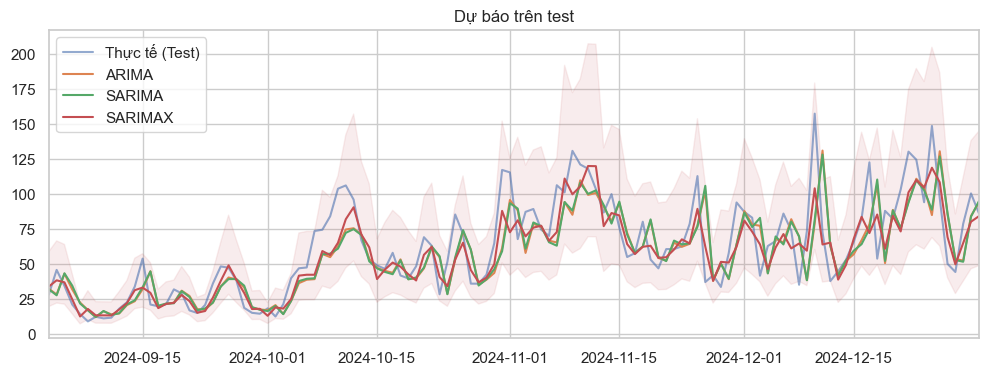

In [9]:
# CELL 9: chạy 3 mô hình, in MAE/RMSE/sMAPE và vẽ so sánh

# 1) Chuẩn bị exog_final theo sel_final từ CELL 7
exog_final = sel_final.copy()

# (tuỳ chọn) nếu muốn chắc chắn có PM10_lag1:
if 'PM10_lag1' in exog_df.columns and 'PM10_lag1' not in exog_final:
    exog_final.append('PM10_lag1')

print("Exog cuối cùng sử dụng:", exog_final)

# 2) Chuẩn hoá exog và align index y_train / y_test
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(exog_df.loc[y_train.index, exog_final])

exog_scaled_all = pd.DataFrame(
    scaler.transform(exog_df[exog_final]),
    index=exog_df.index,
    columns=exog_final
)

exog_scaled_all = exog_scaled_all.replace([np.inf, -np.inf], np.nan)
exog_scaled_all = exog_scaled_all.fillna(method='bfill').fillna(method='ffill')

exog_train_sel = exog_scaled_all.loc[y_train.index] if len(exog_final) > 0 else None
exog_test_sel  = exog_scaled_all.loc[y_test.index]  if len(exog_final) > 0 else None

# 3) ARIMA walk-forward (không exog)
print("Chạy ARIMA walk-forward", order0)
pred_arima, lo_ar, hi_ar, t_ar = forecast_walkforward(
    y_train, y_test,
    order=order0,
    seasonal_order=(0, 0, 0, 0),
    exog_train=None,
    exog_test=None,
)

# 4) SARIMA walk-forward (không exog)
seasonal_candidate = seasonal0 if seasonal0 != (0, 0, 0, 0) else (1, 0, 1, 7)
print("Chạy SARIMA walk-forward", order0, seasonal_candidate)
pred_sarima, lo_s, hi_s, t_s = forecast_walkforward(
    y_train, y_test,
    order=order0,
    seasonal_order=seasonal_candidate,
    exog_train=None,
    exog_test=None,
)

# 5) SARIMAX walk-forward (có exog)
pred_sarimax = lo_x = hi_x = None
t_x = None

if (exog_train_sel is not None) and (exog_train_sel.shape[1] > 0):
    # Đảm bảo không còn NaN trong exog
    assert exog_train_sel.isna().sum().sum() == 0
    assert exog_test_sel.isna().sum().sum() == 0

    print("Chạy SARIMAX walk-forward với exog")
    pred_sarimax, lo_x, hi_x, t_x = forecast_walkforward(
        y_train, y_test,
        order=order0,
        seasonal_order=seasonal_candidate,
        exog_train=exog_train_sel,
        exog_test=exog_test_sel,
    )
else:
    print("Không có exog -> bỏ SARIMAX")

# 6) Tính metric trên thang gốc
y_test_goc = inv_transform(y_test)

results = []
results.append({
    'model': 'ARIMA',
    'mae':   mean_absolute_error(y_test_goc, pred_arima),
    'rmse':  rmse(y_test_goc, pred_arima),
    'sMAPE': sMAPE(y_test_goc, pred_arima),
    'time_s': t_ar
})
results.append({
    'model': 'SARIMA',
    'mae':   mean_absolute_error(y_test_goc, pred_sarima),
    'rmse':  rmse(y_test_goc, pred_sarima),
    'sMAPE': sMAPE(y_test_goc, pred_sarima),
    'time_s': t_s
})

if pred_sarimax is not None:
    results.append({
        'model': 'SARIMAX',
        'mae':   mean_absolute_error(y_test_goc, pred_sarimax),
        'rmse':  rmse(y_test_goc, pred_sarimax),
        'sMAPE': sMAPE(y_test_goc, pred_sarimax),
        'time_s': t_x
    })

res_df = pd.DataFrame(results).sort_values('mae').reset_index(drop=True)
print("Bảng so sánh (sắp theo MAE):")
print(res_df)

# 7) Vẽ so sánh (zoom 120 ngày cuối)
plt.figure(figsize=(12, 4))
plt.plot(y_test_goc, label='Thực tế (Test)', color='C0', alpha=0.6)
plt.plot(pred_arima,  label='ARIMA',  color='C1')
plt.plot(pred_sarima, label='SARIMA', color='C2')

if pred_sarimax is not None:
    plt.plot(pred_sarimax, label='SARIMAX', color='C3')
    if (lo_x is not None) and (hi_x is not None):
        plt.fill_between(pred_sarimax.index, lo_x, hi_x, color='C3', alpha=0.1)

plt.legend()
plt.title('Dự báo trên test')
plt.xlim(y_test_goc.index[-120], y_test_goc.index[-1])
plt.show()


In [10]:


def rmse_safe(y_true, y_pred):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    # align: nếu có NaN hoặc khác dài, lấy phần đồng thời không-NaN
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))

# sMAPE (nếu chưa có)
def sMAPE(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if mask.sum() == 0:
        return np.nan
    yt = y_true[mask]; yp = y_pred[mask]
    return np.mean(2*np.abs(yp - yt) / (np.abs(yt) + np.abs(yp) + 1e-8)) * 100

# build results an toàn (dùng rmse_safe)
y_test_goc = inv_transform(y_test)  # đã có trước

results = []
# đảm bảo pred_* là numpy / series với cùng index; nếu không, dùng .values
for name, pred, t in [('ARIMA', pred_arima, t_ar), ('SARIMA', pred_sarima, t_s)]:
    # align by index if preds are Series
    if hasattr(pred, 'index'):
        # reindex pred to y_test_goc index (won't create leak, chỉ align)
        pred_aligned = pred.reindex(y_test_goc.index)
    else:
        pred_aligned = pd.Series(pred, index=y_test_goc.index)

    mae = mean_absolute_error(y_test_goc.values, pred_aligned.values)
    rm = rmse_safe(y_test_goc.values, pred_aligned.values)
    sm = sMAPE(y_test_goc.values, pred_aligned.values)
    results.append({'model':name, 'mae':mae, 'rmse':rm, 'sMAPE':sm, 'time_s':t})

# nếu bạn có pred_sarimax, thêm tương tự
if 'pred_sarimax' in globals() and pred_sarimax is not None:
    pred = pred_sarimax
    if hasattr(pred, 'index'):
        pred_aligned = pred.reindex(y_test_goc.index)
    else:
        pred_aligned = pd.Series(pred, index=y_test_goc.index)
    mae = mean_absolute_error(y_test_goc.values, pred_aligned.values)
    rm = rmse_safe(y_test_goc.values, pred_aligned.values)
    sm = sMAPE(y_test_goc.values, pred_aligned.values)
    results.append({'model':'SARIMAX','mae':mae,'rmse':rm,'sMAPE':sm,'time_s':t_x})

res_df = pd.DataFrame(results).sort_values('mae').reset_index(drop=True)
print("Bảng so sánh:")
print(res_df)


Bảng so sánh:
     model        mae       rmse      sMAPE      time_s
0  SARIMAX  11.351932  15.437878  21.701613  208.594745
1    ARIMA  15.372079  21.401862  28.791032    8.995018
2   SARIMA  15.445157  21.519195  28.706778   15.794378


Model tốt nhất: SARIMAX MAE: 11.351932385245503
                                     SARIMAX Results                                      
Dep. Variable:                               PM25   No. Observations:                  584
Model:             SARIMAX(1, 1, 2)x(1, 0, [], 7)   Log Likelihood                 -83.160
Date:                            Fri, 05 Dec 2025   AIC                            202.319
Time:                                    17:31:56   BIC                            280.698
Sample:                                01-01-2023   HQIC                           232.888
                                     - 08-06-2024                                         
Covariance Type:                              opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
PM10                 0.1902      0.007     27.790     

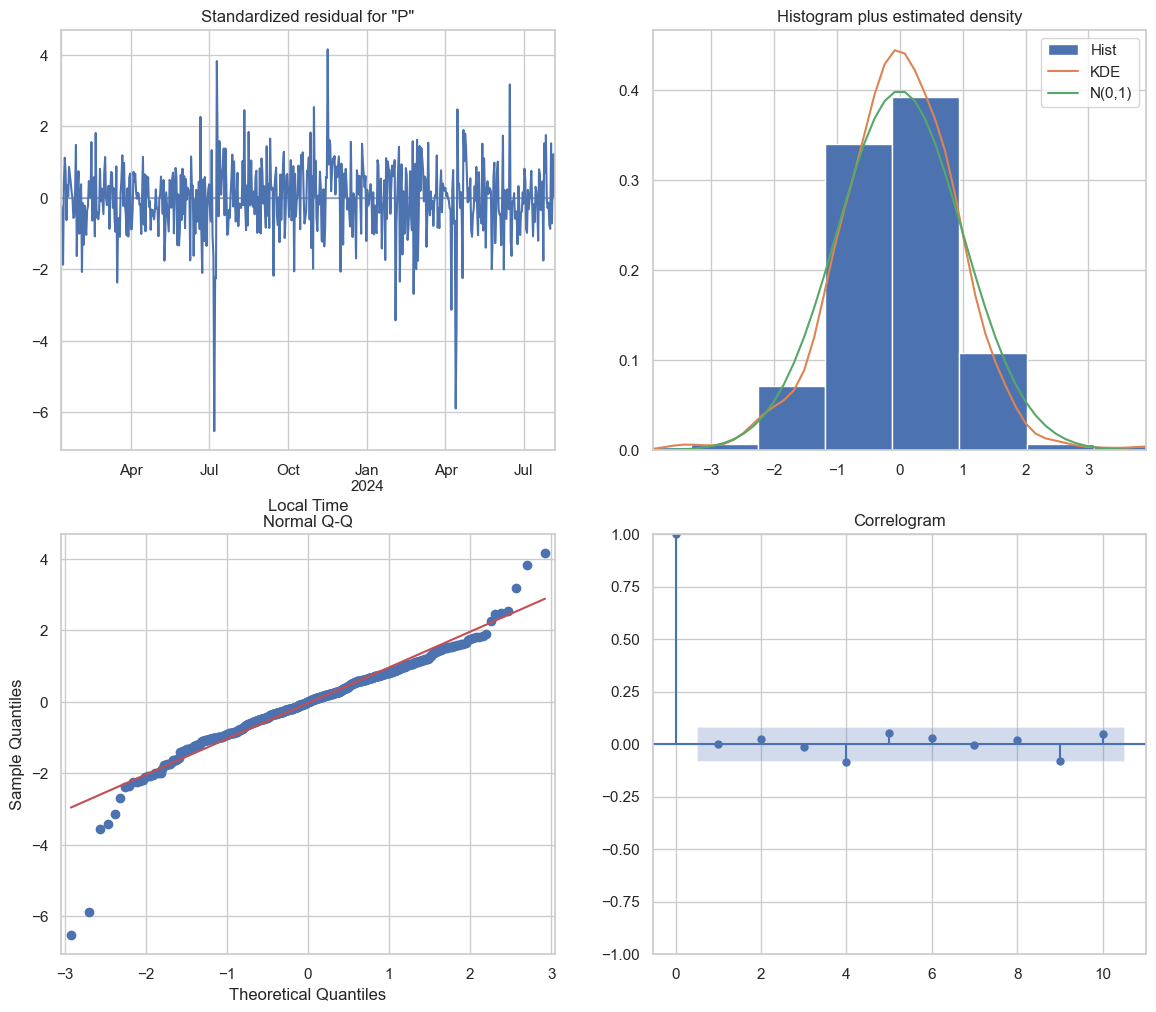

Ljung-Box p(12): 0.07629551101508439
Jarque-Bera p: 0.0 skew: 2.8927167149145743 kurtosis: 48.4788421080558


In [11]:
  # CELL 10: diagnostics cho model tốt nhất và lưu model + kết quả
best = res_df.iloc[0]
print("Model tốt nhất:", best['model'], "MAE:", best['mae'])

# Fit lại final model trên y_train (transform)
if best['model'] == 'ARIMA':
    model_final = SARIMAX(y_train, order=order0, seasonal_order=(0,0,0,0),
                          enforce_stationarity=False, enforce_invertibility=False)
elif best['model'] == 'SARIMA':
    model_final = SARIMAX(y_train, order=order0, seasonal_order=seasonal_candidate,
                          enforce_stationarity=False, enforce_invertibility=False)
else:  # SARIMAX
    model_final = SARIMAX(y_train, exog=exog_train_sel, order=order0, seasonal_order=seasonal_candidate,
                          enforce_stationarity=False, enforce_invertibility=False)

res_final = model_final.fit(disp=False)
print(res_final.summary())

# Vẽ diagnostics (residuals)
res_final.plot_diagnostics(figsize=(14,12))
plt.show()

# Kiểm Ljung-Box và Jarque-Bera để kiểm residual
p_lb = float(acorr_ljungbox(res_final.resid.dropna(), lags=[12], return_df=True)["lb_pvalue"].iloc[0])
jb_stat, jb_p, skew, kurt = jarque_bera(res_final.resid.dropna())
print("Ljung-Box p(12):", p_lb)
print("Jarque-Bera p:", jb_p, "skew:", skew, "kurtosis:", kurt)



In [ ]:
from utils_pm25 import build_pm25_daily, build_exog_daily


best_order = (1, 1, 2)
best_seasonal = (0, 0, 1, 7)
best_exog_cols = exog_final

y_train_tf = y_train.astype(float).copy()

# exog tương ứng cho train (đã scale ở CELL 9)
exog_train_best = None
if (exog_train_sel is not None) and (len(best_exog_cols) > 0):
    exog_train_best = exog_train_sel[best_exog_cols].astype(float)

best_model = SARIMAX(
    y_train_tf,
    exog=exog_train_best,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_res = best_model.fit(maxiter=200, disp=False)

df = pd.read_csv("E:\Document\PROJECT_1\data\data (2023-2024).csv")

# PM2.5 theo ngày
pm25_daily = build_pm25_daily(df)
y_full = pm25_daily.copy()

# exog theo ngày
exog_daily = build_exog_daily(df, y_full.index)

# exog_cols từ tuning (đảm bảo là list)
best_exog_cols = list(best_exog_cols)
exog_full = exog_daily[best_exog_cols].copy()

# =============================================
# 2) Chuẩn hóa exog bằng scaler mới ( FULL DATA )
# =============================================
full_scaler = StandardScaler()
full_scaler.fit(exog_full)

exog_full_scaled = pd.DataFrame(
    full_scaler.transform(exog_full),
    index=exog_full.index,
    columns=best_exog_cols
)

# =============================================
# 3) Transform y_full theo log (đúng pipeline trước)
# =============================================
y_full_tf = np.log(y_full + 1e-6)
lam_final = None   # vì không dùng boxcox

# =============================================
# 4) Fit SARIMAX FULL trên toàn bộ dữ liệu
# =============================================
best_model = SARIMAX(
    y_full_tf.astype(float),
    exog=exog_full_scaled.astype(float),
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_res = best_model.fit(maxiter=200, disp=False)

# =============================================
# 5) Save model + scaler + config
# =============================================
root = Path.cwd().parent
model_dir = root / "models"
model_dir.mkdir(exist_ok=True)

joblib.dump(best_res, model_dir / "sarimax_pm25.pkl")
joblib.dump(full_scaler, model_dir / "exog_scaler.pkl")

config = {
    "order": best_order,
    "seasonal_order": best_seasonal,
    "transform": "log",
    "lam": lam_final,
    "exog_cols": best_exog_cols
}

with open(model_dir / "config_pm25.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("Đã lưu model: ", model_dir)